In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
#from sklearn.linear_model import LinearRegression
#from sklearn.metrics import r2_score
#import datetime as dt
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, f1_score, classification_report 
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb
from sklearn.model_selection import GridSearchCV

scaler = MinMaxScaler()

In [2]:
df = pd.read_excel('/Users/gokul/Documents/code/python/BA_PR/loan_data.xlsx')

In [3]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [5]:
df = df.loc[:, df.columns != "Loan_ID"]

In [6]:
df['CoapplicantIncome'].value_counts()

CoapplicantIncome
0.0       273
2500.0      5
2083.0      5
1666.0      5
2250.0      3
         ... 
2791.0      1
1010.0      1
1695.0      1
2598.0      1
240.0       1
Name: count, Length: 287, dtype: int64

In [7]:
df['Loan_Amount_Term'].value_counts()

Loan_Amount_Term
360.0    512
180.0     44
480.0     15
300.0     13
240.0      4
84.0       4
120.0      3
60.0       2
36.0       2
12.0       1
Name: count, dtype: int64

In [8]:
df.drop('CoapplicantIncome', axis=1, inplace=True)
df.drop('Loan_Amount_Term', axis=1, inplace=True)
df.Credit_History = df.Credit_History.astype('bool')
df.dropna(inplace=True)
len(df)

535

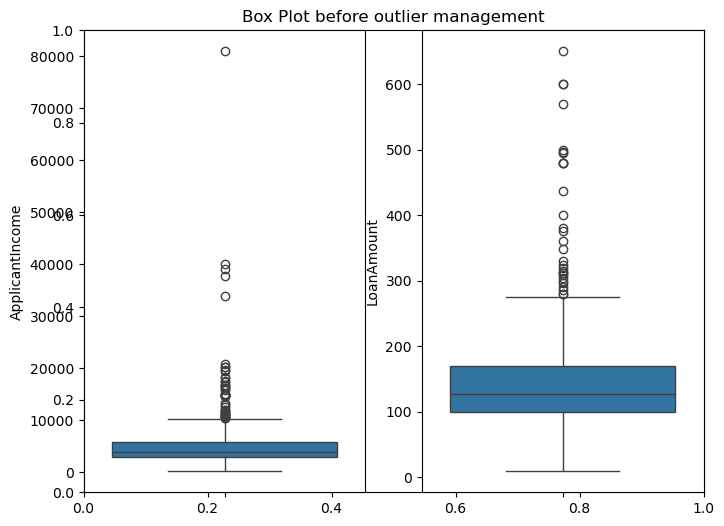

In [9]:
plt.figure(figsize=(8, 6))
plt.title("Box Plot before outlier management")
plt.subplot(1,2,1)
sns.boxplot(data=df['ApplicantIncome'])
plt.subplot(1,2,2)
sns.boxplot(data=df['LoanAmount'])

# Show the plot
plt.show()

In [10]:
def outlierMgmt(dataF):
    
    for c in dataF.columns:
        if (dataF[c].dtype == 'int64' or dataF[c].dtype == 'float'):
            
            dataF = dataF[np.abs(stats.zscore(dataF[c])) < 3] # 3sd removal
            
            q1 = dataF[c].quantile(.25)
            q3 = dataF[c].quantile(.75)
            iqr = q3 - q1
            
            if iqr == 0:
                dataF.drop(c, axis=1, inplace=True)
                print("Dropped", c)
                continue
                
            upper = q3 + 1.5 * iqr
            lower = q1 - 1.5 * iqr
            dataF = dataF[((dataF[c] > lower) & (dataF[c] < upper))] # 1.5 iqr removal
            
    return dataF
df2 = outlierMgmt(df)


In [11]:
len(df2)

464

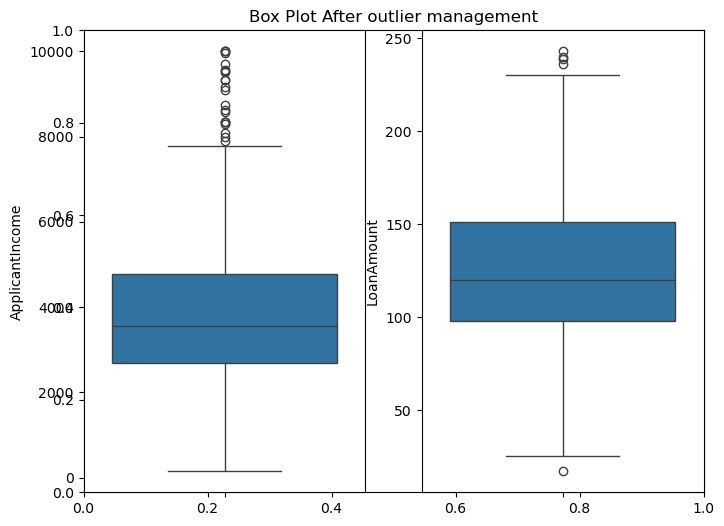

In [12]:
plt.figure(figsize=(8, 6))
plt.title("Box Plot After outlier management")
plt.subplot(1,2,1)
sns.boxplot(data=df2['ApplicantIncome'])
plt.subplot(1,2,2)
sns.boxplot(data=df2['LoanAmount'])

# Show the plot
plt.show()

array([[<Axes: title={'center': 'ApplicantIncome'}>,
        <Axes: title={'center': 'LoanAmount'}>]], dtype=object)

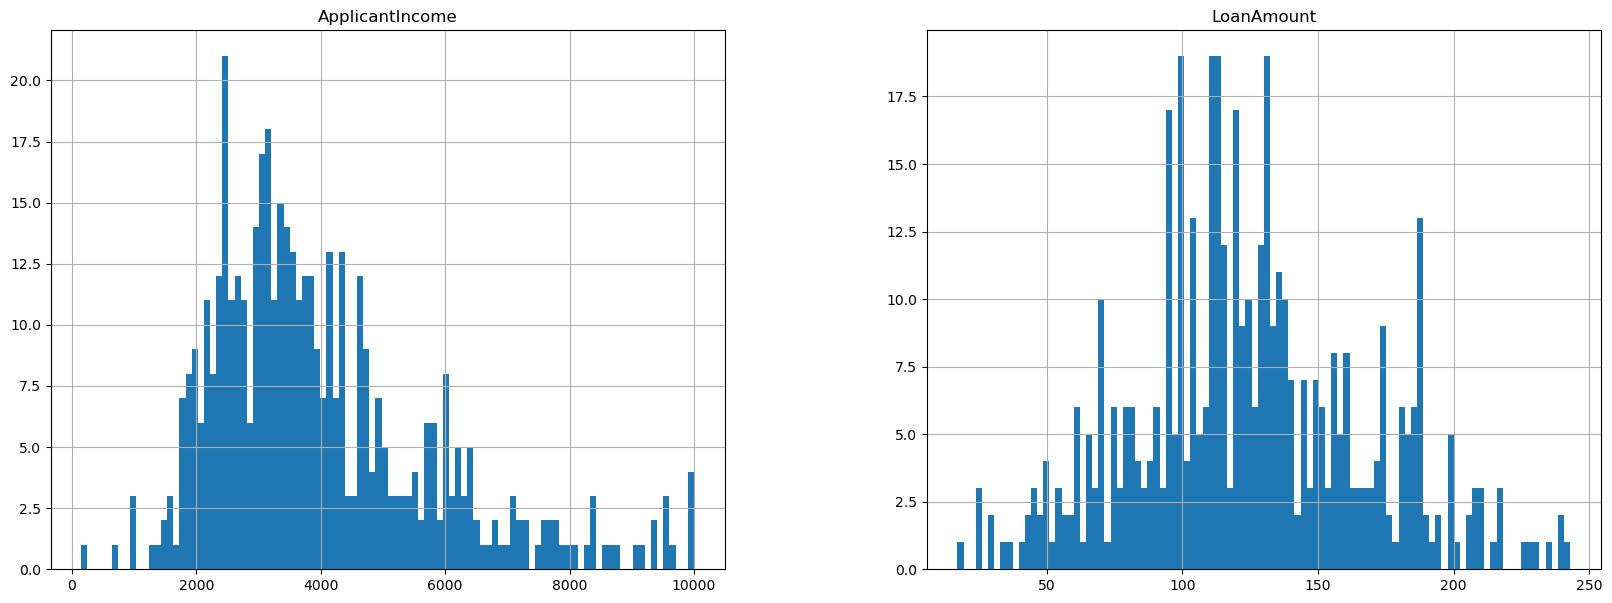

In [13]:
df2.hist(bins=100, figsize=(20,7))

In [14]:
print(df2.dtypes)

Gender              object
Married             object
Dependents          object
Education           object
Self_Employed       object
ApplicantIncome      int64
LoanAmount         float64
Credit_History        bool
Property_Area       object
Loan_Status         object
dtype: object


In [15]:
print(df2.describe())

       ApplicantIncome  LoanAmount
count       464.000000  464.000000
mean       3997.428879  124.204741
std        1809.149444   42.605518
min         150.000000   17.000000
25%        2698.750000   98.000000
50%        3559.500000  120.000000
75%        4770.500000  151.000000
max       10000.000000  243.000000


In [16]:
df2['Loan_Status'].value_counts()

Loan_Status
Y    329
N    135
Name: count, dtype: int64

In [17]:
len(df2)

464

In [18]:
df3 = pd.concat([df2, df2[df2['Loan_Status'] == 'N']], ignore_index=True) # sample duplication

In [19]:
df3['Loan_Status'].value_counts()

Loan_Status
Y    329
N    270
Name: count, dtype: int64

In [20]:
df3 = pd.get_dummies(df3, drop_first=True)
#df2.select_dtypes(exclude = ['bool'])

In [21]:
df3.columns

Index(['ApplicantIncome', 'LoanAmount', 'Credit_History', 'Gender_Male',
       'Married_Yes', 'Dependents_1', 'Dependents_2', 'Dependents_3+',
       'Education_Not Graduate', 'Self_Employed_Yes',
       'Property_Area_Semiurban', 'Property_Area_Urban', 'Loan_Status_Y'],
      dtype='object')

In [22]:
df3_binary = df3.drop(columns = ['ApplicantIncome', 'LoanAmount', 'Loan_Status_Y' ])
df3_quant = df3[['ApplicantIncome', 'LoanAmount']]
df3_lab = df3[['Loan_Status_Y']]

In [23]:
# Binary to continuous correlation:
quantDF = df3_quant
labDF = df3_lab

for q in range(len(quantDF.columns)):
    
    correlation, p_value = stats.pointbiserialr(labDF.iloc[:,0], quantDF.iloc[:,q])
    print(f"Point-Biserial Correlation between {quantDF.columns[q]} and  {labDF.columns[0]} is : {correlation}") 
    print(f"P-value: {p_value}")
    print("\n-------------------------------------------\n")

Point-Biserial Correlation between ApplicantIncome and  Loan_Status_Y is : 0.03255704099644658
P-value: 0.4264023831359239

-------------------------------------------

Point-Biserial Correlation between LoanAmount and  Loan_Status_Y is : -0.00955968813779306
P-value: 0.8153848310026007

-------------------------------------------



In [24]:
# Binary to binary association test:

binDF = df3_binary
labDF = df3_lab

alpha = 0.05
for b in range(len(binDF.columns)):

    cont_tab = pd.crosstab(binDF.iloc[:,b], labDF.iloc[:,0])
    chi2, p, dof, ex = stats.chi2_contingency(cont_tab)
    print(f"Chi-squared value between {binDF.columns[b]} and  {labDF.columns[0]} is : {chi2}") 
    print(f"P-value: {p}")

    if p < alpha:
        print(f"Reject the null hypothesis (H0): There is a relationship between {binDF.columns[b]} and {labDF.columns[0]}.")
    else:
        print(f"Fail to reject the null hypothesis (H0): There is no relationship between {binDF.columns[b]} and {labDF.columns[0]}.")
    print("\n-------------------------------------------\n")


Chi-squared value between Credit_History and  Loan_Status_Y is : 159.62400539423925
P-value: 1.3670966362322367e-36
Reject the null hypothesis (H0): There is a relationship between Credit_History and Loan_Status_Y.

-------------------------------------------

Chi-squared value between Gender_Male and  Loan_Status_Y is : 2.94467317123736
P-value: 0.0861611266904165
Fail to reject the null hypothesis (H0): There is no relationship between Gender_Male and Loan_Status_Y.

-------------------------------------------

Chi-squared value between Married_Yes and  Loan_Status_Y is : 5.582956839932906
P-value: 0.018136077586316753
Reject the null hypothesis (H0): There is a relationship between Married_Yes and Loan_Status_Y.

-------------------------------------------

Chi-squared value between Dependents_1 and  Loan_Status_Y is : 2.6450602203271933
P-value: 0.10387222086563243
Fail to reject the null hypothesis (H0): There is no relationship between Dependents_1 and Loan_Status_Y.

-----------

In [25]:
#features selected: Credit_History, Married_Yes, Education_Not Graduate, Property_Area_Semiurban
fdf = df3[['Credit_History', 'Married_Yes', 'Education_Not Graduate', 'Property_Area_Semiurban', 'Loan_Status_Y']]

In [26]:
import pandas as pd
import scipy.stats as stats
import itertools


def chi2_test_between_columns(df):
    columns = df.columns
    results = {}

    for col1, col2 in itertools.combinations(columns, 2):
        contingency_table = pd.crosstab(df[col1], df[col2])
        chi2, p, dof, ex = stats.chi2_contingency(contingency_table)
        results[(col1, col2)] = {'chi2': chi2, 'p_value': p}
    
    return results

results = chi2_test_between_columns(fdf)

for key, value in results.items():
    print(f"Chi-squared test between {key[0]} and {key[1]}: chi2 = {value['chi2']}, p-value = {value['p_value']}")


Chi-squared test between Credit_History and Married_Yes: chi2 = 0.174841889989383, p-value = 0.6758440349870407
Chi-squared test between Credit_History and Education_Not Graduate: chi2 = 3.2667126016103913, p-value = 0.07069916495038918
Chi-squared test between Credit_History and Property_Area_Semiurban: chi2 = 0.7478256694674372, p-value = 0.3871655110145342
Chi-squared test between Credit_History and Loan_Status_Y: chi2 = 159.62400539423925, p-value = 1.3670966362322367e-36
Chi-squared test between Married_Yes and Education_Not Graduate: chi2 = 0.8212353030703768, p-value = 0.36481923967693697
Chi-squared test between Married_Yes and Property_Area_Semiurban: chi2 = 0.005960439272951137, p-value = 0.9384613541104526
Chi-squared test between Married_Yes and Loan_Status_Y: chi2 = 5.582956839932906, p-value = 0.018136077586316753
Chi-squared test between Education_Not Graduate and Property_Area_Semiurban: chi2 = 1.2034684064063166, p-value = 0.272629556018336
Chi-squared test between Edu

In [27]:
# plt.figure(figsize=(12, 8))
# sns.heatmap(df3.corr(), fmt='.2f', annot=True, cmap='RdYlGn')
# plt.show

In [28]:
df3 = df3.sample(frac=1)
df3.reset_index(drop=True, inplace=True)
X_train, X_test,y_train,y_test = train_test_split(df3.loc[:,df3.columns != 'Loan_Status_Y'],df3['Loan_Status_Y'],test_size =0.2)

In [29]:
#Feature scaling
x_train = scaler.fit_transform(pd.DataFrame(X_train))
x_test = scaler.transform(pd.DataFrame(X_test))

In [30]:
x_test

array([[0.2977665 , 0.48878924, 1.        , ..., 0.        , 0.        ,
        1.        ],
       [0.31472081, 0.68609865, 1.        , ..., 0.        , 0.        ,
        0.        ],
       [0.28395939, 0.23766816, 0.        , ..., 0.        , 0.        ,
        1.        ],
       ...,
       [0.2319797 , 0.26008969, 1.        , ..., 0.        , 0.        ,
        1.        ],
       [1.        , 0.88340807, 1.        , ..., 0.        , 1.        ,
        0.        ],
       [0.38071066, 0.32735426, 1.        , ..., 0.        , 1.        ,
        0.        ]])

In [31]:
x_train.shape

(479, 12)

In [32]:
model1 = GaussianNB()
model1.fit(x_train, y_train)

GaussianNB()

In [33]:
def evaluationMetrics(model):
    
    y_pred = model.predict(x_test)
    accuray = accuracy_score(y_pred, y_test)
    f1 = f1_score(y_pred, y_test, average="weighted")
    
    print("Accuracy:", accuray)
    print("F1 Score:", f1)
    
    labels = [0,1]
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot()
    
    
    target_names = ['class 0', 'class 1']
    print(classification_report(y_test, y_pred, target_names=target_names))

Accuracy: 0.7416666666666667
F1 Score: 0.7620229463787745
              precision    recall  f1-score   support

     class 0       0.85      0.46      0.60        50
     class 1       0.71      0.94      0.81        70

    accuracy                           0.74       120
   macro avg       0.78      0.70      0.70       120
weighted avg       0.77      0.74      0.72       120



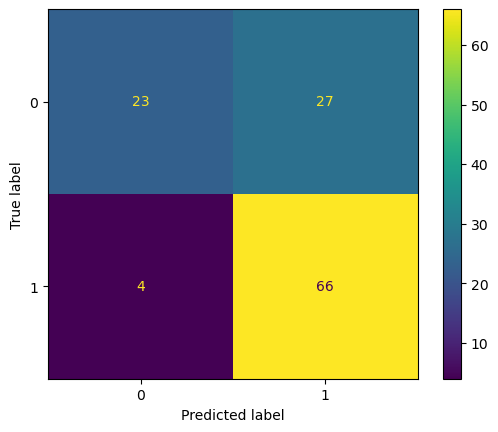

In [34]:
evaluationMetrics(model1)

In [40]:
np.logspace(0,-9, num=100)

array([1.00000000e+00, 8.11130831e-01, 6.57933225e-01, 5.33669923e-01,
       4.32876128e-01, 3.51119173e-01, 2.84803587e-01, 2.31012970e-01,
       1.87381742e-01, 1.51991108e-01, 1.23284674e-01, 1.00000000e-01,
       8.11130831e-02, 6.57933225e-02, 5.33669923e-02, 4.32876128e-02,
       3.51119173e-02, 2.84803587e-02, 2.31012970e-02, 1.87381742e-02,
       1.51991108e-02, 1.23284674e-02, 1.00000000e-02, 8.11130831e-03,
       6.57933225e-03, 5.33669923e-03, 4.32876128e-03, 3.51119173e-03,
       2.84803587e-03, 2.31012970e-03, 1.87381742e-03, 1.51991108e-03,
       1.23284674e-03, 1.00000000e-03, 8.11130831e-04, 6.57933225e-04,
       5.33669923e-04, 4.32876128e-04, 3.51119173e-04, 2.84803587e-04,
       2.31012970e-04, 1.87381742e-04, 1.51991108e-04, 1.23284674e-04,
       1.00000000e-04, 8.11130831e-05, 6.57933225e-05, 5.33669923e-05,
       4.32876128e-05, 3.51119173e-05, 2.84803587e-05, 2.31012970e-05,
       1.87381742e-05, 1.51991108e-05, 1.23284674e-05, 1.00000000e-05,
      

In [35]:
param = {'var_smoothing': np.logspace(0,-9, num=100)}
model1_tuned = GridSearchCV(estimator=model1, 
                 param_grid=param, 
                 # cv=cv_method,
                 verbose=1, 
                 scoring='precision') 
model1_tuned.fit(x_train, y_train)

print(model1_tuned.best_params_)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
{'var_smoothing': 0.533669923120631}


Accuracy: 0.75
F1 Score: 0.771181001283697
              precision    recall  f1-score   support

     class 0       0.88      0.46      0.61        50
     class 1       0.71      0.96      0.82        70

    accuracy                           0.75       120
   macro avg       0.80      0.71      0.71       120
weighted avg       0.78      0.75      0.73       120



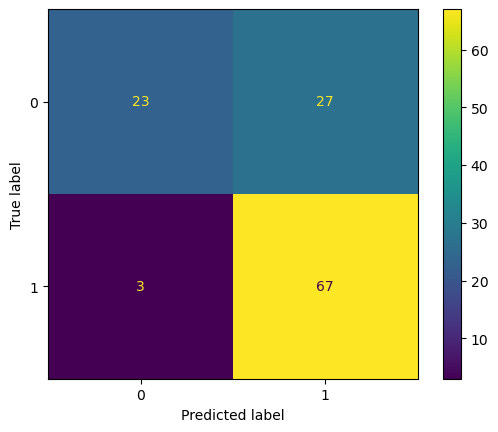

In [36]:
evaluationMetrics(model1_tuned)

In [37]:
model2 = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss') # error
model2.fit(x_train, y_train)
----------------------------------
# Define parameter grid
param_grid = {
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 200, 300],
    'gamma': [0.01, 0.001, 0, 0.1, 0.2, 0.3]
}


model2_tuned = GridSearchCV(estimator=model2, param_grid=param_grid, scoring='accuracy', cv=3, verbose=1)

model2_tuned.fit(x_train, y_train)

print("Best parameters found: ", model2_tuned.best_params_)
print("Best score found: ", model2_tuned.best_score_)


Fitting 3 folds for each of 162 candidates, totalling 486 fits


/Users/gokul/anaconda3/envs/gk_pyt/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [13:00:03] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1730232611148/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/gokul/anaconda3/envs/gk_pyt/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [13:00:04] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1730232611148/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/gokul/anaconda3/envs/gk_pyt/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [13:00:04] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1730232611148/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/gokul/anaconda3/envs/gk_pyt/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [13:00:04] WARNING: /Us

Best parameters found:  {'gamma': 0.1, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}
Best score found:  0.8433831236897275


/Users/gokul/anaconda3/envs/gk_pyt/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [13:01:13] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1730232611148/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy: 0.85
F1 Score: 0.8489510489510489
              precision    recall  f1-score   support

     class 0       0.77      0.92      0.84        50
     class 1       0.93      0.80      0.86        70

    accuracy                           0.85       120
   macro avg       0.85      0.86      0.85       120
weighted avg       0.86      0.85      0.85       120



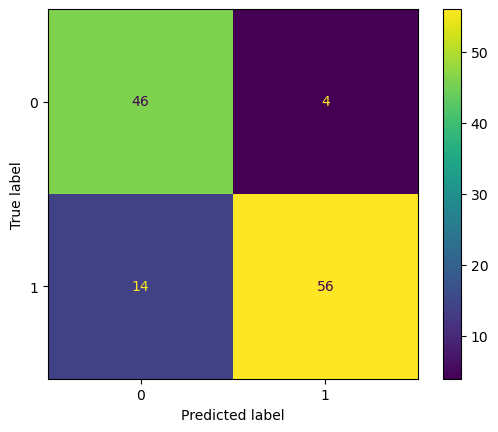

In [38]:
evaluationMetrics(model2)

Accuracy: 0.8666666666666667
F1 Score: 0.8658781563878719
              precision    recall  f1-score   support

     class 0       0.80      0.90      0.85        50
     class 1       0.92      0.84      0.88        70

    accuracy                           0.87       120
   macro avg       0.86      0.87      0.86       120
weighted avg       0.87      0.87      0.87       120



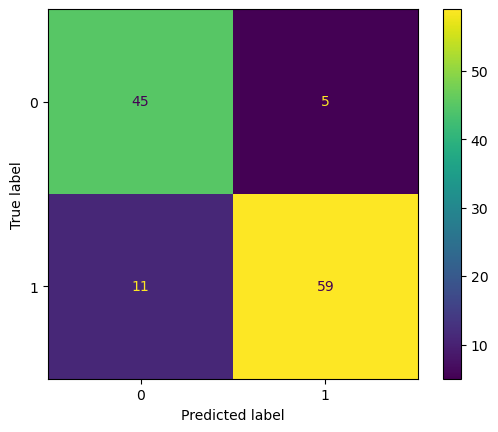

In [39]:
evaluationMetrics(model2_tuned)